# Word2Vec
Word2Vec는 유사성을 가진 단어들을 벡터로 표현한 것입니다

# Collect Data
우리는 단어 벡터를 생성하기 위해 10개의 문장만 사용할 것입니다

In [2]:
corpus = ['king is a strong man', 
          'queen is a wise woman', 
          'boy is a young man',
          'girl is a young woman',
          'prince is a young king',
          'princess is a young queen',
          'man is strong', 
          'woman is pretty',
          'prince is a boy will be king',
          'princess is a girl will be queen']

# Remove stop words
단어 벡터 생성의 효율성을 위해, 자주 사용되는 단어들은 제거할 것입니다

In [3]:
a = ["aa", "bb", "aa","cc"]
b = a.index("cc") 

print(b)

3


In [4]:
a = ["aa bb aa cc", "is cc kk is"]

def remove_stop_words2(corpus):
    stop_words = ['is', 'a', 'will', 'be', 'aa']
    results = []
    for text in corpus:
        tmp = text.split(' ')
        for stop_word in stop_words:
            if stop_word in tmp:
                tmp.remove(stop_word)
        results.append(" ".join(tmp))
    
    return results

remove_stop_words2(a)

['bb aa cc', 'cc kk is']

위의 함수가 'aa'와 'is'를 모두 제거하지 못했습니다.

아래에서 제대로 함수를 작성해 주세요.

In [5]:
a = ["aa bb aa cc", "is cc kk is"]

def remove_stop_words(corpus):
    stop_words = ["aa", "is"]
    result = []
    for sentence in corpus:
        words = sentence.split()
        filtered = [word for word in words if word not in stop_words]
        result.append(" ".join(filtered))
    return result

print(remove_stop_words(a))
# ['bb cc', 'cc kk']


['bb cc', 'cc kk']


In [6]:
corpus = remove_stop_words(corpus)

In [7]:
corpus

['king a strong man',
 'queen a wise woman',
 'boy a young man',
 'girl a young woman',
 'prince a young king',
 'princess a young queen',
 'man strong',
 'woman pretty',
 'prince a boy will be king',
 'princess a girl will be queen']

corpus를 공백을 기준으로 token화 하고 같은 단어가 반복해서 나오지 않도록 집합으로 만들어 주세요

In [8]:
words = []
# your code here
words = []
for sentence in corpus:
    words += sentence.split()
words = list(set(words))
print(words)

['boy', 'girl', 'wise', 'will', 'young', 'a', 'princess', 'strong', 'man', 'prince', 'woman', 'queen', 'king', 'pretty', 'be']


집합을 다시 리스트로 만들어 주세요 

In [9]:
words = list(words)
print(words)

['boy', 'girl', 'wise', 'will', 'young', 'a', 'princess', 'strong', 'man', 'prince', 'woman', 'queen', 'king', 'pretty', 'be']


# data generation
우리는 Skip-Gram을 사용하여 각 단어에 대한 레이블을 생성할 것입니다

먼저 위에서 만들어진 words 리스트로 word2int라는 Dictionary를 만들어 주세요. key는 단어이고, value는 index 입니다.

In [10]:
word2int = {}
# your code here
for i, word in enumerate(words):
    word2int[word] = i
sentences = []
for sentence in corpus:
    sentences.append(sentence.split())
print(word2int)
print(sentences)

{'boy': 0, 'girl': 1, 'wise': 2, 'will': 3, 'young': 4, 'a': 5, 'princess': 6, 'strong': 7, 'man': 8, 'prince': 9, 'woman': 10, 'queen': 11, 'king': 12, 'pretty': 13, 'be': 14}
[['king', 'a', 'strong', 'man'], ['queen', 'a', 'wise', 'woman'], ['boy', 'a', 'young', 'man'], ['girl', 'a', 'young', 'woman'], ['prince', 'a', 'young', 'king'], ['princess', 'a', 'young', 'queen'], ['man', 'strong'], ['woman', 'pretty'], ['prince', 'a', 'boy', 'will', 'be', 'king'], ['princess', 'a', 'girl', 'will', 'be', 'queen']]


input 과 target 쌍으로 이루어진 리스트를 만듭니다.

In [11]:
WINDOW_SIZE = 2

data = []
for sentence in sentences:
    for idx, word in enumerate(sentence):
        for neighbor in sentence[max(idx - WINDOW_SIZE, 0) : min(idx + WINDOW_SIZE, len(sentence)) + 1] : 
            if neighbor != word:
                data.append([word, neighbor])

print(len(data))
data

100


[['king', 'a'],
 ['king', 'strong'],
 ['a', 'king'],
 ['a', 'strong'],
 ['a', 'man'],
 ['strong', 'king'],
 ['strong', 'a'],
 ['strong', 'man'],
 ['man', 'a'],
 ['man', 'strong'],
 ['queen', 'a'],
 ['queen', 'wise'],
 ['a', 'queen'],
 ['a', 'wise'],
 ['a', 'woman'],
 ['wise', 'queen'],
 ['wise', 'a'],
 ['wise', 'woman'],
 ['woman', 'a'],
 ['woman', 'wise'],
 ['boy', 'a'],
 ['boy', 'young'],
 ['a', 'boy'],
 ['a', 'young'],
 ['a', 'man'],
 ['young', 'boy'],
 ['young', 'a'],
 ['young', 'man'],
 ['man', 'a'],
 ['man', 'young'],
 ['girl', 'a'],
 ['girl', 'young'],
 ['a', 'girl'],
 ['a', 'young'],
 ['a', 'woman'],
 ['young', 'girl'],
 ['young', 'a'],
 ['young', 'woman'],
 ['woman', 'a'],
 ['woman', 'young'],
 ['prince', 'a'],
 ['prince', 'young'],
 ['a', 'prince'],
 ['a', 'young'],
 ['a', 'king'],
 ['young', 'prince'],
 ['young', 'a'],
 ['young', 'king'],
 ['king', 'a'],
 ['king', 'young'],
 ['princess', 'a'],
 ['princess', 'young'],
 ['a', 'princess'],
 ['a', 'young'],
 ['a', 'queen'],
 ['y

In [12]:
import pandas as pd

df = pd.DataFrame(data, columns = ['input', 'label'])
df

,input,label
0,king,a
1,king,strong
2,a,king
3,a,strong
4,a,man
...,...,...
95,be,girl
96,be,will
97,be,queen
98,queen,will


In [13]:
df.shape

(100, 2)

In [14]:
word2int

{'boy': 0,
 'girl': 1,
 'wise': 2,
 'will': 3,
 'young': 4,
 'a': 5,
 'princess': 6,
 'strong': 7,
 'man': 8,
 'prince': 9,
 'woman': 10,
 'queen': 11,
 'king': 12,
 'pretty': 13,
 'be': 14}

# Define Tensorflow Graph

이 코드는 TensorFlow를 사용하여 단어 임베딩(Word Embedding)을 학습하는 간단한 신경망 모델을 구현한 것입니다. 모델은 입력으로 주어진 원핫 인코딩(One-Hot Encoding)된 단어 벡터를 저차원 임베딩 공간으로 매핑하고, 그 임베딩 벡터를 사용하여 단어를 예측하는 과정을 학습합니다. 이 코드에서는 특히 2차원 공간에 임베딩을 학습하여 시각화하기 위한 목적으로 설계되었습니다.

In [15]:
import tensorflow as tf
import numpy as np

ONE_HOT_DIM = len(words)

# function to convert numbers to one hot vectors
def to_one_hot_encoding(data_point_index):
    one_hot_encoding = np.zeros(ONE_HOT_DIM)
    one_hot_encoding[data_point_index] = 1
    return one_hot_encoding

X = [] # input word
Y = [] # target word

for x, y in zip(df['input'], df['label']):
    X.append(to_one_hot_encoding(word2int[ x ]))
    Y.append(to_one_hot_encoding(word2int[ y ]))

print('X :', X)
print('Y :', Y)
# convert them to tensors
X_train = tf.convert_to_tensor(X, dtype=tf.float32)
Y_train = tf.convert_to_tensor(Y, dtype=tf.float32)

# word embedding will be 2 dimension for 2d visualization
EMBEDDING_DIM = 2 

# hidden layer: which represents word vector eventually
W1 = tf.Variable(tf.random.normal([ONE_HOT_DIM, EMBEDDING_DIM]))  # 12 X 2
b1 = tf.Variable(tf.random.normal([1]), dtype=tf.float32) #bias

# output layer
W2 = tf.Variable(tf.random.normal([EMBEDDING_DIM, ONE_HOT_DIM]))  # 2 X 12
b2 = tf.Variable(tf.random.normal([1]), dtype=tf.float32)

# define optimizer
optimizer = tf.optimizers.SGD(learning_rate=0.05)


X : [array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 1.

# Train

이 코드는 TensorFlow를 사용하여 신경망(Neural Network)을 훈련하는 과정입니다. 여기서는 단일 은닉층을 가진 신경망을 통해 입력 데이터를 학습시키고, 모델의 가중치를 경사하강법(Gradient Descent)을 통해 업데이트하는 작업을 수행합니다. 이 과정은 분류 문제를 해결하기 위한 소프트맥스(Softmax) 활성화 함수를 사용하여 확률 분포를 출력합니다.

In [16]:
iteration = 20000

for i in range(iteration):
    with tf.GradientTape() as tape:
        hidden_layer = tf.add(tf.matmul(X_train, W1), b1)
        prediction = tf.nn.softmax(tf.add(tf.matmul(hidden_layer, W2), b2))

        loss_value = tf.reduce_mean(-tf.reduce_sum(Y_train * tf.math.log(prediction), axis=[1]))

    grads = tape.gradient(loss_value, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

    if i % 3000 == 0:
        print(f'Iteration {i}, Loss: {loss_value.numpy()}')


Iteration 0, Loss: 7.158377170562744
Iteration 3000, Loss: 2.252347707748413
Iteration 6000, Loss: 2.1607131958007812
Iteration 9000, Loss: 2.126403570175171
Iteration 12000, Loss: 2.1046979427337646
Iteration 15000, Loss: 2.0923306941986084
Iteration 18000, Loss: 2.0838582515716553


In [17]:
vectors = W1 + b1
print(vectors.numpy())

[[ 0.0361433  -1.8537325 ]
 [ 0.03816926 -1.8529261 ]
 [-3.1154213  -3.3085651 ]
 [-2.4784963  -3.267465  ]
 [-2.604379   -3.1427665 ]
 [-0.21649158 -0.19920146]
 [-1.834457   -3.4627962 ]
 [-1.9599364  -1.8583629 ]
 [ 2.2916799  -2.5388298 ]
 [-1.8966682  -3.5194216 ]
 [ 3.4959893  -3.0571032 ]
 [ 1.7404153  -2.052499  ]
 [ 1.3290248  -2.0385659 ]
 [-3.5737329   0.13166714]
 [-0.73106885 -0.9753724 ]]


# word vector in table

In [18]:
w2v_df = pd.DataFrame(vectors, columns = ['x1', 'x2'])
w2v_df['word'] = words
w2v_df = w2v_df[['word', 'x1', 'x2']]
w2v_df

,word,x1,x2
0,boy,0.036143,-1.853732
1,girl,0.038169,-1.852926
2,wise,-3.115421,-3.308565
3,will,-2.478496,-3.267465
4,young,-2.604379,-3.142766
5,a,-0.216492,-0.199201
6,princess,-1.834457,-3.462796
7,strong,-1.959936,-1.858363
8,man,2.291680,-2.538830
9,prince,-1.896668,-3.519422


# word vector in 2d chart

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16356\912592063.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 12)


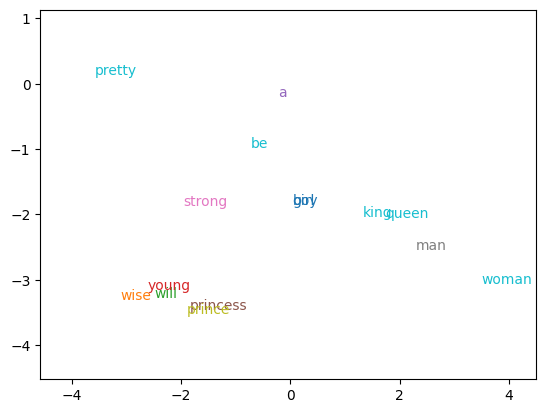

In [19]:
import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('tab10', 12)
fig, ax = plt.subplots()

for i, (word, x1, x2) in enumerate(zip(w2v_df['word'], w2v_df['x1'], w2v_df['x2'])):
    ax.annotate(word, (x1,x2 ), color=colors(i))
    
PADDING = 1.0
x_axis_min = np.amin(vectors, axis=0)[0] - PADDING
y_axis_min = np.amin(vectors, axis=0)[1] - PADDING
x_axis_max = np.amax(vectors, axis=0)[0] + PADDING
y_axis_max = np.amax(vectors, axis=0)[1] + PADDING
 
plt.xlim(x_axis_min,x_axis_max)
plt.ylim(y_axis_min,y_axis_max)
plt.rcParams["figure.figsize"] = (10,10)

plt.show()